##### ARTI 560 - Computer Vision

## Visual Representations with DINOv2 - Exercise

### Exercise 1: Unsupervised Clustering

In this exercise, you will use the `KMeans` algorithm from sklearn to group 20 images from the Oxford Pet dataset into 2 clusters (Cats vs. Dogs) based purely on their CLS tokens.

Instructions:

1.  Extract the 384-dimensional [CLS] tokens from 20 images of the Oxford-IIIT Pet dataset. Ensure your selection includes a mix of both cats and dogs.

2. Apply K-Means Clustering ($n=2$) to group the vectors based on mathematical similarity rather than provided labels.

3. Compare the predicted clusters against ground-truth labels.

In [1]:
!pip install -q transformers datasets scikit-learn matplotlib seaborn pillow requests

Device: cuda


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Model loaded: facebook/dinov2-small


100%|██████████| 792M/792M [00:26<00:00, 30.2MB/s] 
100%|██████████| 19.2M/19.2M [00:01<00:00, 14.8MB/s]


Total cat images: 1188
Total dog images: 2492


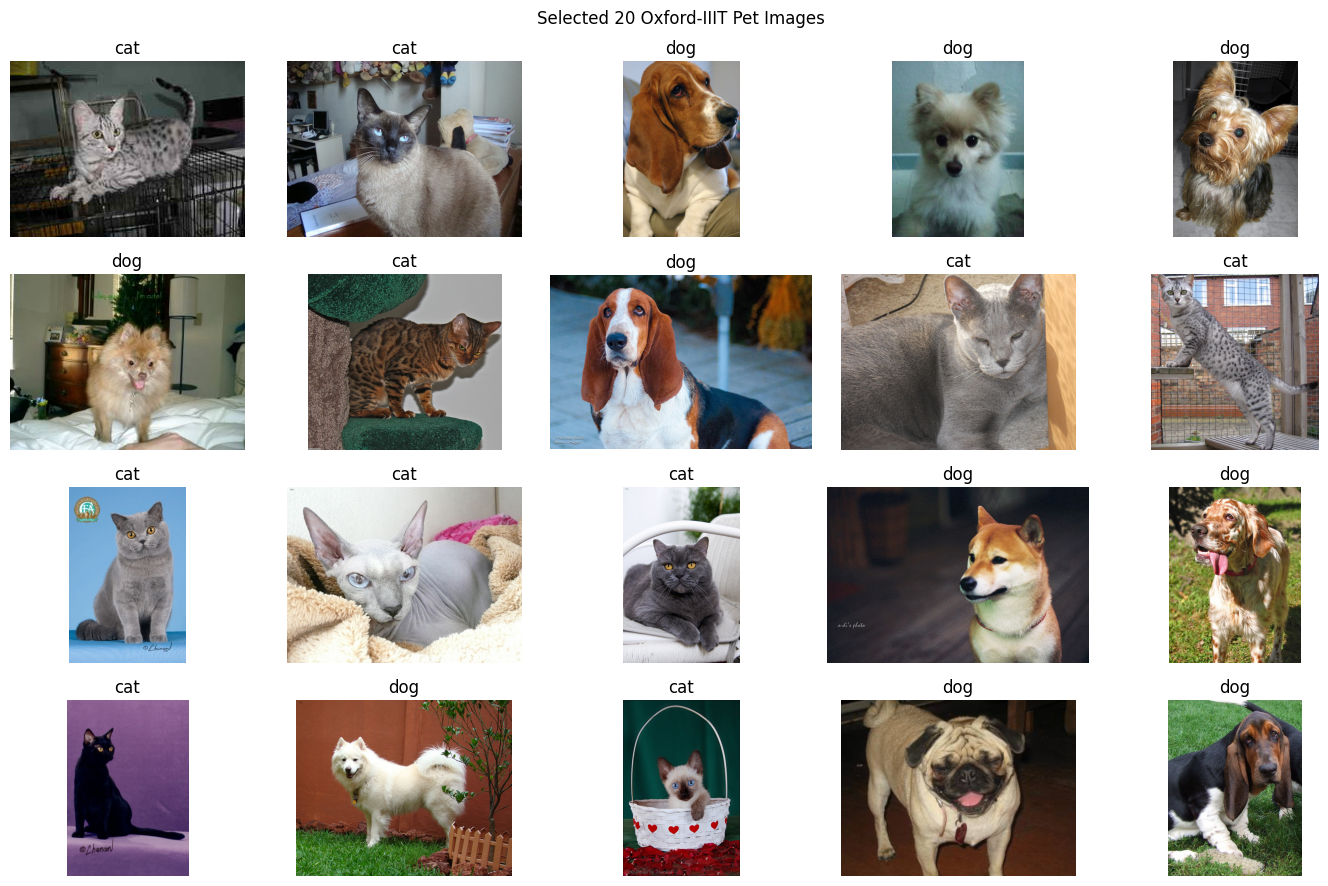

Embeddings shape: (20, 384)
Each image is represented by a 384-dimensional CLS token.


,image,true_label,cluster_id,cluster_mapped_label
0,Egyptian_Mau_171.jpg,cat,1,cat
1,Siamese_106.jpg,cat,1,cat
2,basset_hound_128.jpg,dog,0,dog
3,pomeranian_170.jpg,dog,1,cat
4,yorkshire_terrier_167.jpg,dog,0,dog
5,pomeranian_113.jpg,dog,1,cat
6,Bengal_101.jpg,cat,1,cat
7,basset_hound_120.jpg,dog,0,dog
8,Russian_Blue_111.jpg,cat,1,cat
9,Egyptian_Mau_134.jpg,cat,1,cat


K-Means clustering accuracy after majority mapping: 75.00%

Cluster-to-label mapping: {np.int32(0): 'dog', np.int32(1): 'cat'}

Confusion Matrix:
          Pred cat  Pred dog
True cat        10         0
True dog         5         5

Classification Report:
              precision    recall  f1-score   support

         cat       0.67      1.00      0.80        10
         dog       1.00      0.50      0.67        10

    accuracy                           0.75        20
   macro avg       0.83      0.75      0.73        20
weighted avg       0.83      0.75      0.73        20



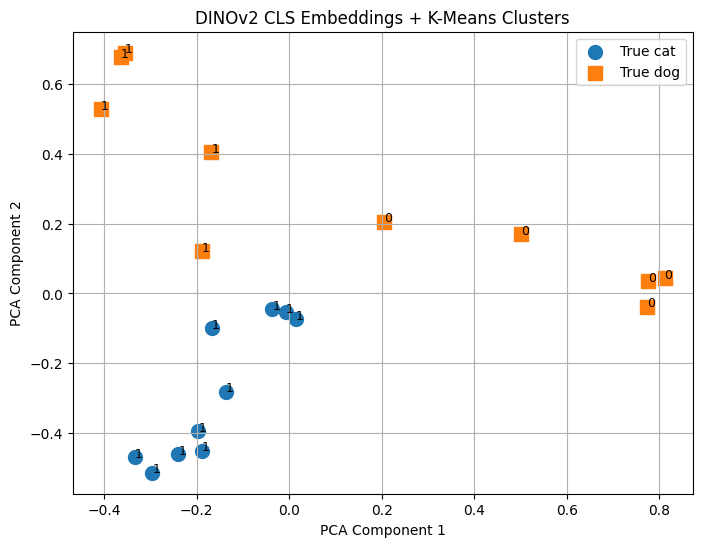

In [1]:
import os
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display

from torchvision.datasets import OxfordIIITPet
from transformers import AutoImageProcessor, AutoModel
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


#1) Setup

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

MODEL_ID = "facebook/dinov2-small"   # DINOv2-small gives a 384-dimensional CLS token

processor = AutoImageProcessor.from_pretrained(MODEL_ID)
model = AutoModel.from_pretrained(MODEL_ID).to(device)
model.eval()

print(f"Model loaded: {MODEL_ID}")


# 2) Download the Oxford-IIIT Pet dataset

dataset = OxfordIIITPet(
    root="data",
    split="trainval",
    target_types="category",
    download=True
)

# Torchvision keeping the image paths in dataset._images
image_paths = [str(p) for p in dataset._images]

# Cat breeds in Oxford-IIIT Pet.
# Tha remaining breeds are dogs.
CAT_BREEDS = {
    "abyssinian", "bengal", "birman", "bombay", "british_shorthair",
    "egyptian_mau", "maine_coon", "persian", "ragdoll",
    "russian_blue", "siamese", "sphynx"
}

def get_pet_type_from_path(path):
    """
    Oxford-IIIT Pet filenames look like:
    Abyssinian_1.jpg, British_Shorthair_10.jpg, american_bulldog_12.jpg

    We remove the final image number and compare the breed name.
    """
    stem = Path(path).stem
    breed = "_".join(stem.split("_")[:-1]).lower()
    return "cat" if breed in CAT_BREEDS else "dog"

all_labels = [get_pet_type_from_path(p) for p in image_paths]

cat_indices = [i for i, label in enumerate(all_labels) if label == "cat"]
dog_indices = [i for i, label in enumerate(all_labels) if label == "dog"]

print("Total cat images:", len(cat_indices))
print("Total dog images:", len(dog_indices))

# Select exactly 20 images: 10 cats + 10 dogs
selected_indices = random.sample(cat_indices, 10) + random.sample(dog_indices, 10)
random.shuffle(selected_indices)

selected_paths = [image_paths[i] for i in selected_indices]
true_labels = [all_labels[i] for i in selected_indices]

# Show the selected images
plt.figure(figsize=(14, 9))
for idx, (path, label) in enumerate(zip(selected_paths, true_labels)):
    img = Image.open(path).convert("RGB")
    plt.subplot(4, 5, idx + 1)
    plt.imshow(img)
    plt.title(label)
    plt.axis("off")
plt.suptitle("Selected 20 Oxford-IIIT Pet Images")
plt.tight_layout()
plt.show()


# 3) Extract 384-dimensional CLS tokens

@torch.no_grad()
def get_global_embedding(path):
    img = Image.open(path).convert("RGB")
    inputs = processor(images=img, return_tensors="pt").to(device)
    outputs = model(**inputs)

    # The first token is the [CLS] token: one vector representing the whole image
    cls_token = outputs.last_hidden_state[:, 0, :]
    cls_token = F.normalize(cls_token, p=2, dim=1)
    return cls_token.squeeze(0).cpu().numpy()

embeddings = np.vstack([get_global_embedding(path) for path in selected_paths])

print("Embeddings shape:", embeddings.shape)
print("Each image is represented by a 384-dimensional CLS token.")


# 4) Apply K-Means with n=2 clusters (for cat and dog)

kmeans = KMeans(n_clusters=2, random_state=SEED, n_init=10)
cluster_ids = kmeans.fit_predict(embeddings)

# Cluster numbers are arbitrary, so we map each cluster to cat/dog by majority vote.
cluster_to_label = {}
for cluster in sorted(set(cluster_ids)):
    labels_in_cluster = [true_labels[i] for i, c in enumerate(cluster_ids) if c == cluster]
    majority_label = Counter(labels_in_cluster).most_common(1)[0][0]
    cluster_to_label[cluster] = majority_label

predicted_labels = [cluster_to_label[c] for c in cluster_ids]


# 5) Compare clusters with ground-truth labels

results_df = pd.DataFrame({
    "image": [Path(p).name for p in selected_paths],
    "true_label": true_labels,
    "cluster_id": cluster_ids,
    "cluster_mapped_label": predicted_labels
})

display(results_df)

accuracy = accuracy_score(true_labels, predicted_labels)
print(f"K-Means clustering accuracy after majority mapping: {accuracy * 100:.2f}%")
print("\nCluster-to-label mapping:", cluster_to_label)

print("\nConfusion Matrix:")
print(pd.DataFrame(
    confusion_matrix(true_labels, predicted_labels, labels=["cat", "dog"]),
    index=["True cat", "True dog"],
    columns=["Pred cat", "Pred dog"]
))

print("\nClassification Report:")
print(classification_report(true_labels, predicted_labels))


# 6) Visualize embeddings in 2D using PCA

pca = PCA(n_components=2, random_state=SEED)
embeddings_2d = pca.fit_transform(embeddings)

plt.figure(figsize=(8, 6))
for label, marker in [("cat", "o"), ("dog", "s")]:
    mask = np.array(true_labels) == label
    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        marker=marker,
        s=100,
        label=f"True {label}"
    )

for i, cluster in enumerate(cluster_ids):
    plt.text(
        embeddings_2d[i, 0],
        embeddings_2d[i, 1],
        str(cluster),
        fontsize=9
    )

plt.title("DINOv2 CLS Embeddings + K-Means Clusters")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.grid(True)
plt.show()


### Exercise 2: Image Classification with DINOv2

In this exercise you'll use a DINOv2 model with a pre-trained linear head to classify an image. You will observe how the model maps visual features to specific ImageNet-1k categories.

Instructions:
1. For this exercise, you must use the following Model ID. This specific checkpoint includes the necessary classification head trained on ImageNet-1k:

    Model ID: `facebook/dinov2-small-imagenet1k-1-layer`

2. Find an image online to make the inference. To ensure the model has a fair chance of success, the image should belong to one of the ImageNet-1k classes (e.g., a Golden Retriever, a grand piano, a school bus, or a coffee mug).

Device: cuda


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/91.3M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/225 [00:00<?, ?it/s]

Classification model loaded: facebook/dinov2-small-imagenet1k-1-layer
Loaded image from: https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg


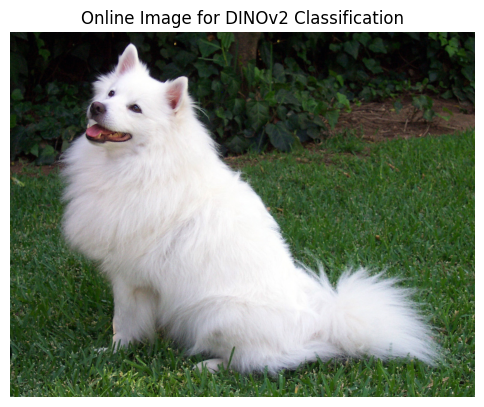


Top-5 ImageNet-1k Predictions:
1. Samoyed, Samoyede - 67.40%
2. Pomeranian - 25.70%
3. keeshond - 2.47%
4. Great Pyrenees - 1.36%
5. Japanese spaniel - 0.93%

Final Prediction: Samoyed, Samoyede (67.40%)


In [2]:
import torch
import requests
import matplotlib.pyplot as plt
from PIL import Image
from io import BytesIO
from transformers import AutoImageProcessor, AutoModelForImageClassification


# 1) Setup classification model

CLASSIFICATION_MODEL_ID = "facebook/dinov2-small-imagenet1k-1-layer"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

clf_processor = AutoImageProcessor.from_pretrained(CLASSIFICATION_MODEL_ID)
clf_model = AutoModelForImageClassification.from_pretrained(CLASSIFICATION_MODEL_ID).to(device)
clf_model.eval()

print(f"Classification model loaded: {CLASSIFICATION_MODEL_ID}")


# 2) Load an online image

# This image is an online dog image from the PyTorch examples.
# Dog breeds are part of ImageNet-1k, so the model has a fair chance to classify it correctlyy.
IMAGE_URLS = [
    "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg",
    "https://github.com/pytorch/hub/raw/master/images/dog.jpg",
]

def load_online_image(urls):
    headers = {"User-Agent": "Mozilla/5.0"}
    last_error = None

    for url in urls:
        try:
            response = requests.get(url, headers=headers, timeout=30)
            response.raise_for_status()
            image = Image.open(BytesIO(response.content)).convert("RGB")
            print("Loaded image from:", url)
            return image
        except Exception as e:
            last_error = e
            print("Failed to load:", url)

    raise FileNotFoundError(
        "Could not download the online image. "
        "Try changing IMAGE_URLS to another direct image URL. "
        f"Last error: {last_error}"
    )

image = load_online_image(IMAGE_URLS)

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.title("Online Image for DINOv2 Classification")
plt.axis("off")
plt.show()


# 3) Run the inference

inputs = clf_processor(images=image, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = clf_model(**inputs)
    logits = outputs.logits
    probabilities = torch.softmax(logits, dim=-1)


# 4) Print Top-5 predictions

top5 = torch.topk(probabilities, k=5, dim=-1)

print("\nTop-5 ImageNet-1k Predictions:")
for rank, (score, class_idx) in enumerate(zip(top5.values[0], top5.indices[0]), start=1):
    label = clf_model.config.id2label[class_idx.item()]
    confidence = score.item() * 100
    print(f"{rank}. {label} - {confidence:.2f}%")

predicted_idx = top5.indices[0][0].item()
predicted_label = clf_model.config.id2label[predicted_idx]
predicted_confidence = top5.values[0][0].item() * 100

print(f"\nFinal Prediction: {predicted_label} ({predicted_confidence:.2f}%)")
